## Figures from 1D Loop experiments

In [43]:
# Imports
import sys # for path management
import os

# Add HandcraftApproach directory to path
ha_path = os.path.abspath("/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach")
if ha_path not in sys.path:
    sys.path.insert(0, ha_path)

import importlib
import MazeAgent_HA as MA
importlib.reload(MA)

import copy
import tomplotlib.tomplotlib as tpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import imageio
import random
import pandas as pd
from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

#for plotting in notebook
%matplotlib inline

# define a list of random seeds to loop through for runs of the same experiment
#random_seeds = [0, 42]
random_seeds = [0, 2, 4, 6, 42]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   initialising theta phases: clean and scrambled
   making the maze walls
   setting goal location and reward
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
   Adding 'theta scrambled' Condition
   calculating value function based on distance to goal
DONE


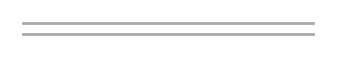

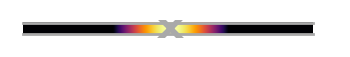

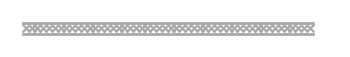

In [53]:
## Define parameters for maze and agent
# number of placeCells
N=50

# set x and y coordinates for place cell centres
xcen = np.linspace(0,5,N+1)[:-1] # we want to place N place cells evenly across the 5m length of the maze, so we create N+1 evenly spaced points and then take all but the last one (which is at 5m) to get the centres of the place cells.
xcen += (xcen[1] - xcen[0]) / 2 # we want the first place cell to be centred at 0.1m, so we shift all the centres by half the distance between them (i.e. the distance between the first centre and 0m) to get the final x coordinates of the place cell centres.
ycen = np.array([0.1]*N) # we want all the place cells to be centred at 0.1m in the y direction (i.e. 10cm from the south wall) so we set all the y coordinates of the place cell centres to 0.1m.
centres = np.vstack((xcen,ycen)).T # we combine the x and y coordinates into a single array of shape (N,2) where each row is the (x,y) coordinates of a place cell centre.



# set parameters for the MazeAgent class
params = {
           #Maze params 
          'mazeType'            : 'loop',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, circles, bump)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : 5,          #maze size scaling parameter, metres
          'dt'                  : 0.01,       #simulation time disretisation (defualts to largest )
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : None,       #rotational speed scale, radians/second
          'initPos'             : None,  #initial position [x0, y0], metres
          'initDir'             : None,      #initial direction, unit vector
          'nCells'              : N,       #how many features to use
          'centres'             : centres,       #array of receptive field positions. Overwrites nCells
          'sigma'               : 1,          #basis cell width scale (irrelevant for onehots)
          'doorsClosed'         : False,       #whether doors are opened or closed in multicompartment maze
          'reorderCells'        : True,       #whether to reorde the cell centres which have been provided
          'firingRateLookUp'    : False,      #use quantised lookup table for firing rates 
          'biasDoorCross'       : False,      #if True, in twoRoom maze door crossings are biased towards
          'biasWallFollow'      : True,       #if True, agent aligns to wall when gets too near.

          #TD params 
          'tau'                 : 4,          #TD decay time, seconds
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres 
          'alpha'               : 0.01,       #TD learning rate 
          'successorFeatureNorm': 100,        #linear scaling on successor feature definition found to improve learning stability
          'TDreg'               : 0.01,       #L2 regularisation 
          
          #STDP params
          'peakFiringRate'      : 5,          #peak firing rate of a cell (middle of place field,preferred theta phase)
          'tau_STDP_plus'       : 20e-3,      # was 20 pre trace decay time
          'tau_STDP_minus'      : 40e-3,      #was 40 post trace decay time
          'a_STDP'              : -0.4,       # was -0.4, pre-before-post potentiation factor (post-before-pre = 1) 
          'eta'                 : 0.01,       #STDP learning rate
          'baselineFiringRate'  : 0,          #baseline firing rate for cells 
          'use_full_STDP_rule'  : True,      #whether to use full STDP rule     
          'online_mapping'      : 'identity',  #how to map CA3-->CA1 during learning
          'rownorm'             : False,

          #Theta precession params
          'thetaFreq'           : 10,         #theta frequency
          'precessFraction'     : 0.5,        #fraction of 2pi the prefered phase moves through
          'kappa'               : 5,          # von mises spread parameter
          
          #Theta scrambling params (Livi addition)
          'scramble_strength'    : 0.6,        # strength of theta phase scrambling 
          'hf_strength'          : 0.6,        # strength of high frequency jitter added to scrambled theta phase

          # Goal Location
          'goalPos'             : [5.25, 8.0], # 7.5 before. position of goal in metres -> given as array of shape [x, y]
          'goalRadius'          : 0.5,       # radius of goal in metres
          'goalReward'          : 1.0,

}

agent_1D = MA.MazeAgent(params)
plotter = MA.Visualiser(agent_1D)
agent_1D.toggleDoors(params['doorsClosed'])

plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(25) # plot receptive field of place cell 5 in the middel of loop
fig= plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)
# save figure
#plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/1DLoop.pdf", transparent=True)
#fig, ax = plotter.plotFeatureCells(shufflebeforeplot=False, textlabel=True)
#plotter.plotGoal()

  0%|          | 0/180000 [00:00<?, ?it/s]

Calculating place and grid cells


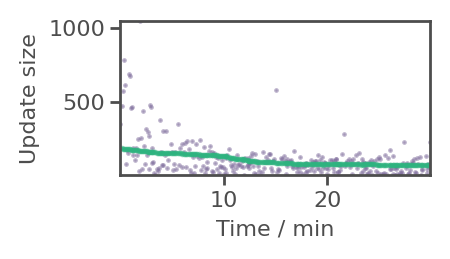

In [54]:
# Set parameters and run simulation
agent_1D.pos = np.array([0,0.1])  
agent_1D.dir = np.array([1,0]) # start at the west end of the loop, facing east, so we can follow the walls in a clockwise direction

# Define agent to train for 30min (as in paper), with STDP learning, no TD learning and save snapshots every 1min
agent_1D.runRat(trainTime=30, STDPLearn=True, TDSRLearn=True, saveEvery=0.5)


(<Figure size 400x400 with 1 Axes>, <Axes: >)

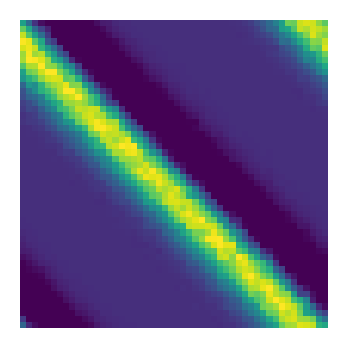

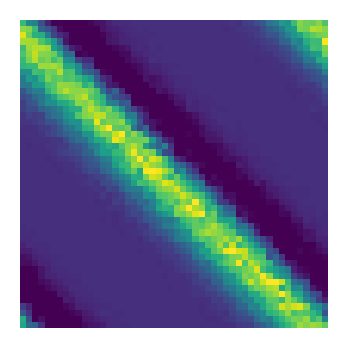

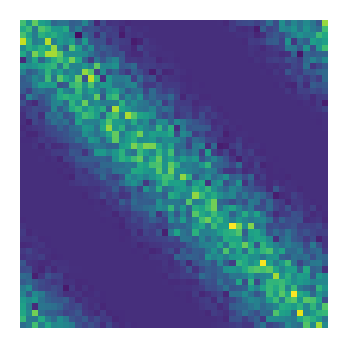

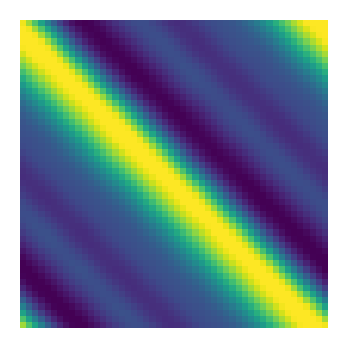

In [55]:
# Define what to plot from this STDP run
plotter = MA.Visualiser(agent_1D) # create new plotter to access the data from the STDP run we just did

# PLOTTING
# plot STDP weight matrix 'W' with clean theta
plotter.plotM(whichM="W", colorbar=False, save=False)
#plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/SR_W_IntactK5_PFR5.pdf", transparent=True)  
# plot basis feature again
#plotter.plotReceptiveField(25)

# plot place field of cell 25 with TD learning 
#fig, ax=plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=False, threshold=0.0)
#ax.set_title("Place field of cell 25 with TD learning", fontsize=12)

# plot place field of cell 25 with STDP learning (clean theta)
#plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=False, threshold=0.0)

# plot place field of cell 25 with STDP learning but no theta modulation 
#plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=True, threshold=0.0)

# scrambled that place field of cell 25 with STDP learning but no theta modulation
#plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=False, scrambled=True, threshold=0.0)

# Plot scrambled
plotter.plotM(whichM="W_scrambled", colorbar=False, save=False) 
plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/SR_W_ST6K5_PFR5.pdf", transparent=True)  


# Plot no_theta
plotter.plotM(whichM="W_notheta", colorbar=False, save=False)

# Plot TD plots
plotter.plotM(whichM="M", colorbar=False, save=False)


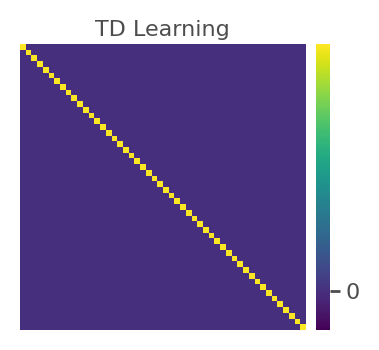

In [21]:
fig= plotter.plotM(whichM="M", colorbar=True, title="TD Learning", save=True)
plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/MatrixColorbar.png", transparent=True)
